# CodeAlpha Machine Learning Internship

## Task 1: Credit Scoring Model

### Name: Kondam Supriya
### Internship: CodeAlpha Machine Learning Internship
### Dataset: German Credit Data Set with Credit Risk
### Tools Used:
- Python
- Google Colab
- Pandas
- NumPy
- Matplotlib
- Scikit-learn

### Objective
Build a machine learning model to predict an individual's creditworthiness using historical financial data.

## Step 1: Import Required Libraries

In this step, we import all the Python libraries required for data analysis, preprocessing, model building, and evaluation.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve
)

## Step 2: Load the Dataset

In this step, we load the German Credit dataset into a Pandas DataFrame for further analysis.

In [2]:
df = pd.read_csv("german_credit_data_updated.csv")

df.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,1
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,2,49,male,1,own,little,NaN,2096,12,education,1
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,4,53,male,2,free,little,little,4870,24,car,2


## Step 3: Explore the Dataset

In this step, we explore the dataset by checking its shape, columns, data types, and basic information.

In [3]:
print("Dataset Shape:", df.shape)

Dataset Shape: (954, 11)


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Unnamed: 0        954 non-null    int64 
 1   Age               954 non-null    int64 
 2   Sex               954 non-null    object
 3   Job               954 non-null    int64 
 4   Housing           954 non-null    object
 5   Saving accounts   779 non-null    object
 6   Checking account  576 non-null    object
 7   Credit amount     954 non-null    int64 
 8   Duration          954 non-null    int64 
 9   Purpose           954 non-null    object
 10  Credit Risk       954 non-null    int64 
dtypes: int64(6), object(5)
memory usage: 82.1+ KB


In [5]:
df.describe()

,Unnamed: 0,Age,Job,Credit amount,Duration,Credit Risk
count,954.000000,954.000000,954.000000,954.000000,954.000000,954.000000
mean,476.500000,35.501048,1.909853,3279.112159,20.780922,1.302935
std,275.540378,11.379668,0.649681,2853.315158,12.046483,0.459768
min,0.000000,19.000000,0.000000,250.000000,4.000000,1.000000
25%,238.250000,27.000000,2.000000,1360.250000,12.000000,1.000000
50%,476.500000,33.000000,2.000000,2302.500000,18.000000,1.000000
75%,714.750000,42.000000,2.000000,3975.250000,24.000000,2.000000
max,953.000000,75.000000,3.000000,18424.000000,72.000000,2.000000


In [6]:
df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,175
Checking account,378
Credit amount,0
Duration,0
Purpose,0


## Step 4: Data Preprocessing

In this step, we handle missing values, remove unnecessary columns, and convert categorical features into numerical values for machine learning.

In [7]:
df["Saving accounts"] = df["Saving accounts"].fillna("unknown")
df["Checking account"] = df["Checking account"].fillna("unknown")

df.isnull().sum()

,0
Unnamed: 0,0
Age,0
Sex,0
Job,0
Housing,0
Saving accounts,0
Checking account,0
Credit amount,0
Duration,0
Purpose,0


In [8]:
df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,male,2,own,unknown,little,1169,6,radio/TV,1
1,22,female,2,own,little,moderate,5951,48,radio/TV,2
2,49,male,1,own,little,unknown,2096,12,education,1
3,45,male,2,free,little,little,7882,42,furniture/equipment,1
4,53,male,2,free,little,little,4870,24,car,2


In [9]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_columns = ["Sex", "Housing", "Saving accounts", "Checking account", "Purpose"]

for col in categorical_columns:
    df[col] = le.fit_transform(df[col])

df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Credit Risk
0,67,1,2,1,4,0,1169,6,5,1
1,22,0,2,1,0,1,5951,48,5,2
2,49,1,1,1,0,3,2096,12,3,1
3,45,1,2,0,0,0,7882,42,4,1
4,53,1,2,0,0,0,4870,24,1,2


In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 954 entries, 0 to 953
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               954 non-null    int64
 1   Sex               954 non-null    int64
 2   Job               954 non-null    int64
 3   Housing           954 non-null    int64
 4   Saving accounts   954 non-null    int64
 5   Checking account  954 non-null    int64
 6   Credit amount     954 non-null    int64
 7   Duration          954 non-null    int64
 8   Purpose           954 non-null    int64
 9   Credit Risk       954 non-null    int64
dtypes: int64(10)
memory usage: 74.7 KB


## Step 5: Feature Selection

In this step, we separate the input features (X) and the target variable (y). The target variable is **Credit Risk**, which the model will learn to predict.

In [11]:
X = df.drop("Credit Risk", axis=1)
y = df["Credit Risk"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (954, 9)
Target Shape: (954,)


## Step 6: Split the Dataset

The dataset is divided into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (763, 9)
Testing Data: (191, 9)


## Step 7: Train Logistic Regression Model

In this step, we train a Logistic Regression model using the training dataset.

In [13]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [14]:
y_pred = model.predict(X_test)

## Step 8: Model Evaluation

In this step, we evaluate the performance of the Logistic Regression model using different evaluation metrics.

In [15]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7539267015706806


In [16]:
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))

Precision: 0.7682119205298014
Recall: 0.90625
F1 Score: 0.8315412186379928


In [17]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.77      0.91      0.83       128
           2       0.70      0.44      0.54        63

    accuracy                           0.75       191
   macro avg       0.73      0.68      0.69       191
weighted avg       0.75      0.75      0.74       191



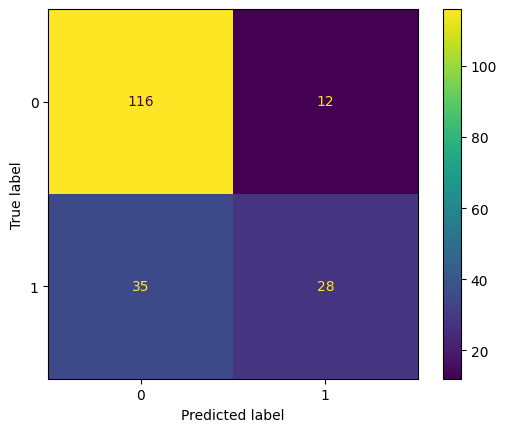

In [18]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [19]:
y_prob = model.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_prob)

print("ROC-AUC Score:", roc_auc)

ROC-AUC Score: 0.7671130952380953


## Step 9: Decision Tree Model

In this step, we train and evaluate a Decision Tree Classifier and compare its performance with Logistic Regression.

In [20]:
from sklearn.tree import DecisionTreeClassifier

dt_model = DecisionTreeClassifier(random_state=42)

dt_model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [21]:
dt_pred = dt_model.predict(X_test)

In [22]:
print("Decision Tree Accuracy:", accuracy_score(y_test, dt_pred))
print("Precision:", precision_score(y_test, dt_pred))
print("Recall:", recall_score(y_test, dt_pred))
print("F1 Score:", f1_score(y_test, dt_pred))

Decision Tree Accuracy: 0.6701570680628273
Precision: 0.7338129496402878
Recall: 0.796875
F1 Score: 0.7640449438202247


In [23]:
print(classification_report(y_test, dt_pred))

              precision    recall  f1-score   support

           1       0.73      0.80      0.76       128
           2       0.50      0.41      0.45        63

    accuracy                           0.67       191
   macro avg       0.62      0.60      0.61       191
weighted avg       0.66      0.67      0.66       191



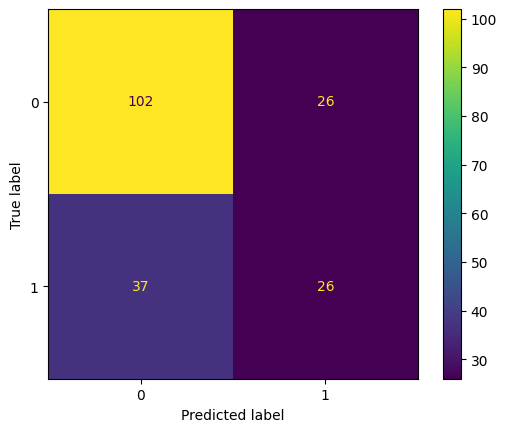

In [24]:
cm = confusion_matrix(y_test, dt_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.show()

In [25]:
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("Decision Tree ROC-AUC Score:", roc_auc_score(y_test, dt_prob))

Decision Tree ROC-AUC Score: 0.6047867063492063


## Step 10: Model Comparison

The performance of Logistic Regression and Decision Tree models is compared using Accuracy, Precision, Recall, F1-Score, and ROC-AUC Score.

In [26]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, dt_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.753927,0.768212,0.906250,0.831541,0.767113
1,Decision Tree,0.670157,0.733813,0.796875,0.764045,0.604787


Step 11: Final Conclusion

A Credit Scoring Model was successfully developed using two machine learning algorithms: Logistic Regression and Decision Tree.

After preprocessing the dataset, both models were trained and evaluated using Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and ROC-AUC Score.

The comparison shows which algorithm performs better for predicting customer credit risk on this dataset.

This project successfully satisfies the requirements of CodeAlpha Machine Learning Internship – Task 1.